## Chains With LangGraph

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Chain using LangGraph"

- ## How to use chat messages as our Graph State

1. content - content of the message
2. name - specify the name of the author
3. response_metadata - optoinal, a dict of metadata

In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content= f"Please tell me how can I Help?", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name="Navneet"))
messages.append(AIMessage(content= f"Which programming language you want to learn", name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn Python Programming langauge", name="Navneet"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I Help?
================================ Human Message =================================
Name: Navneet

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Navneet

I want to learn Python Programming langauge


- ## Chat Models

We can use the sequence of messages as input with the chatmodels using LLM's 

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model= os.getenv('GROQ_MODEL'), api_key= os.getenv('GROQ_API_KEY'))
response = llm.invoke(messages)

In [5]:
response.response_metadata

{'token_usage': {'completion_tokens': 656,
  'prompt_tokens': 78,
  'total_tokens': 734,
  'completion_time': 1.466338468,
  'completion_tokens_details': None,
  'prompt_time': 0.003718128,
  'prompt_tokens_details': None,
  'queue_time': 0.165151831,
  'total_time': 1.470056596},
 'model_name': 'llama-3.3-70b-versatile',
 'system_fingerprint': 'fp_3272ea2d91',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

- ## Tools

Tools can be integrated with the LLM models to interact with external systems. External systems can be APIs, third parth tools

In [6]:
def add(a:int, b:int)-> int:
    """Add a and b
    Args:
        a(int) : first int
        b(int) : secont int
    
    Returns:
        int
    """
    return a + b

In [7]:
## Binding tool with llm
llm_with_tool = llm.bind_tools([add])
call = llm_with_tool.invoke([HumanMessage(content= f"What is 2 plus 2", name="Navneet")])
call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'xwmv7kkpr',
  'type': 'tool_call'}]

In [8]:
## Using Messages as state
from dataclasses import dataclass
from langchain_core.messages import AnyMessage

@dataclass
class State:
    message: list[AnyMessage]

### **Reducer**

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducers functions to address this.

Reducers allow us to specify how state updates are performed

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built `add_messages` reducer

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the `add_messages` reducer function as metadata.

In [9]:
from langgraph.graph.message import add_messages, AnyMessage
from typing import Annotated
from dataclasses import dataclass

@dataclass
class State:
    messages: Annotated[list[AnyMessage], add_messages]

In [10]:
## Reducers with add_messages
initial_messages = [AIMessage(content= f"Please tell me how can I Help?", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name="Navneet"))
initial_messages

[AIMessage(content='Please tell me how can I Help?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Navneet')]

In [11]:
ai_message= AIMessage(content= f"Which programming language you want to learn", name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [12]:
## It is used to append instead of override
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I Help?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='f5489448-a6c5-4e77-b5f2-0d24d75317ec', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Navneet', id='14792b07-581a-4e57-a13c-3d1b503c18e6'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='383143a7-df1e-44e1-93fc-1f65c7273f59', tool_calls=[], invalid_tool_calls=[])]

In [13]:
## Chatbot Node Functionality
def llm_tool(state: State):
    return {"messages": [llm_with_tool.invoke(state.messages)]}

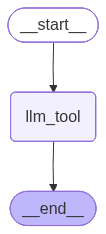

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
## Invocation
messages = graph.invoke({
    "messages": [HumanMessage(content="What is 2 plus 2")]
})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (t6j5124h3)
 Call ID: t6j5124h3
  Args:
    a: 2
    b: 2


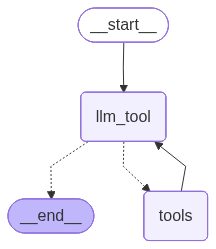

In [16]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

tools = [add]

builder = StateGraph(State)

## Add Node
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

## Add Edge
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges("llm_tool", tools_condition)

#-----------------------------------------------------------------------------------------------------------
## If the latest message (result) from assisstant is a tool call -> tools_condition routes to tools
## If the latest message (result) from assisstant is not a tool call -> tools_condition routes to END
#-----------------------------------------------------------------------------------------------------------

builder.add_edge("tools", "llm_tool")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
## Invocation
messages = graph.invoke({
    "messages": [HumanMessage(content="What is 2 plus 2")]
})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (04t2f2zye)
 Call ID: 04t2f2zye
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

The answer is 4.


In [18]:
## Invocation
messages = graph.invoke({
    "messages": [HumanMessage(content="What is Machine Learning")]
})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from the data it is given, making predictions or decisions based on that data.

There are several types of machine learning, including:

1. **Supervised learning**: The machine is trained on labeled data, where the correct output is already known. The machine learns to map inputs to outputs based on the labeled data.
2. **Unsupervised learning**: The machine is trained on unlabeled data, and it must find patterns or structure in the data on its own.
3. **Reinforcement learning**: The machine learns by interacting with an environment and receiving rewards or penalties for it